# System Mooring DAF

Total mooring force DAF: peak of summed 8-line series divided by sum of static tensions.
Provides context but is less conservative than the individual line DAF.

In [ ]:
import os, glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from pathlib import Path

HEADINGS       = ['0deg', '45deg', '90deg', '135deg', '180deg']
HEADING_LABELS = {'0deg': '0°', '45deg': '45°', '90deg': '90°',
                  '135deg': '135°', '180deg': '180°'}
# Resolve this notebook's folder (works in VS Code and standard Jupyter)
NOTEBOOK_DIR   = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
os.chdir(NOTEBOOK_DIR)
import sys
sys.path.insert(0, str(NOTEBOOK_DIR))
from thesis_style import apply, full, save
apply()
print(f'Working directory: {Path.cwd()}')

In [2]:
g         = 9.81
N_COND    = 10
HS_VALUES = np.linspace(0.5, 3.5, N_COND)

_B = 'BerthedTanker_Catenary'
LINES = {
    'HL7':  {'n':  7,'base':f'{_B}/Run1', 'static':'HL7/StaticResults_HL7_run1-1.h5',    'dynamic':'HL7/DynamicResults_HL7_run1-1.h5',    'lw':7.0,'label':'$H/\\lambda = 1/7$',  'n_cond':9},
    'HL9':  {'n':  9,'base':f'{_B}/Run2', 'static':'HL9/StaticResults_HL9_run2-1.h5',    'dynamic':'HL9/DynamicResults_HL9_run2-1.h5',    'lw':6.5,'label':'$H/\\lambda = 1/9$',  'n_cond':9},
    'HL11': {'n': 11,'base':f'{_B}/Run3', 'static':'HL11/StaticResults_HL11_run3-1.h5',  'dynamic':'HL11/DynamicResults_HL11_run3-1.h5',  'lw':6.0,'label':'$H/\\lambda = 1/11$', 'n_cond':9},
    'HL13': {'n': 13,'base':f'{_B}/Run4', 'static':'HL13/StaticResults_HL13_run4-1.h5',  'dynamic':'HL13/DynamicResults_HL13_run4-1.h5',  'lw':5.5,'label':'$H/\\lambda = 1/13$', 'n_cond':9},
    'HL15': {'n': 15,'base':f'{_B}/Run5', 'static':'HL15/StaticResults_HL15_run5-1.h5',  'dynamic':'HL15/DynamicResults_HL15_run5-1.h5',  'lw':5.0,'label':'$H/\\lambda = 1/15$', 'n_cond':9},
    'HL17': {'n': 17,'base':f'{_B}/Run6', 'static':'HL17/StaticResults_HL17_run6-1.h5',  'dynamic':'HL17/DynamicResults_HL17_run6-1.h5',  'lw':4.5,'label':'$H/\\lambda = 1/17$', 'n_cond':9},
    'HL19': {'n': 19,'base':f'{_B}/Run7', 'static':'HL19/StaticResults_HL19_run7-1.h5',  'dynamic':'HL19/DynamicResults_HL19_run7-1.h5',  'lw':4.0,'label':'$H/\\lambda = 1/19$', 'n_cond':9},
    'HL21': {'n': 21,'base':f'{_B}/Run8', 'static':'HL21/StaticResults_HL21_run8-1.h5',  'dynamic':'HL21/DynamicResults_HL21_run8-1.h5',  'lw':3.5,'label':'$H/\\lambda = 1/21$', 'n_cond':9},
    'HL23': {'n': 23,'base':f'{_B}/Run9', 'static':'HL23/StaticResults_HL23_run9-1.h5',  'dynamic':'HL23/DynamicResults_HL23_run9-1.h5',  'lw':3.2,'label':'$H/\\lambda = 1/23$', 'n_cond':9},
    'HL25': {'n': 25,'base':f'{_B}/Run10','static':'HL25/StaticResults_HL25_run10-1.h5', 'dynamic':'HL25/DynamicResults_HL25_run10-1.h5', 'lw':2.9,'label':'$H/\\lambda = 1/25$', 'n_cond':8},
    'HL27': {'n': 27,'base':f'{_B}/Run11','static':'HL27/StaticResults_HL27_run11-1.h5', 'dynamic':'HL27/DynamicResults_HL27_run11-1.h5', 'lw':2.6,'label':'$H/\\lambda = 1/27$', 'n_cond':7},
    'HL29': {'n': 29,'base':f'{_B}/Run12','static':'HL29/StaticResults_HL29_run12-1.h5', 'dynamic':'HL29/DynamicResults_HL29_run12-1.h5', 'lw':2.3,'label':'$H/\\lambda = 1/29$', 'n_cond':7},
}
MOORING_ELEMS = [f'Mooring{i}' for i in range(1, 9)]
FENDER_ELEMS  = [f'Fender{i}'  for i in range(1, 7)]
TRANSIENT_IDX = int(400 / 0.5)

for cfg in LINES.values():
    nc      = cfg['n_cond']
    Hs_vals = HS_VALUES[:nc]
    Tp_vals = np.sqrt(Hs_vals * 2 * np.pi * cfg['n'] / g)
    cfg['cond_params'] = {
        i+1: (round(float(hs),2), round(float(tp),2))
        for i,(hs,tp) in enumerate(zip(Hs_vals, Tp_vals))
    }

In [3]:
df_all = pd.read_csv('statistics.csv')
df_all['sys_DAF'] = df_all['dyn_max_kN'] / df_all['static_kN']
sys_daf = df_all[['heading','line','cond_num','Hs','Tp','sys_DAF']].copy()
print(f'Loaded {len(sys_daf)} rows')

Loaded 515 rows


## Scatter — System Mooring DAF

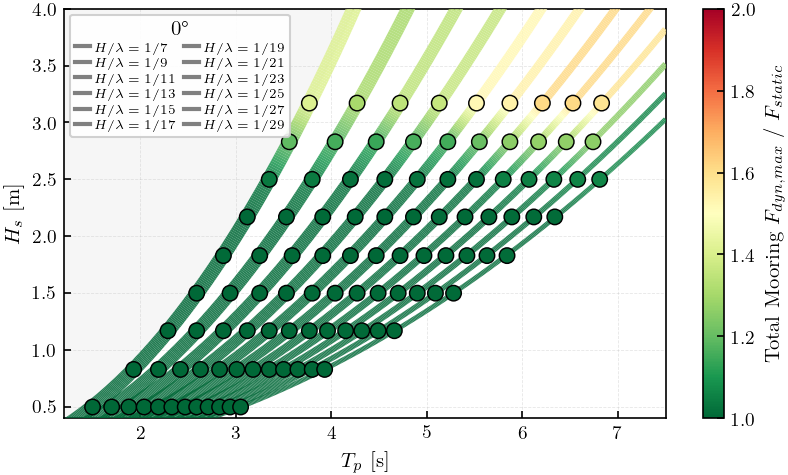

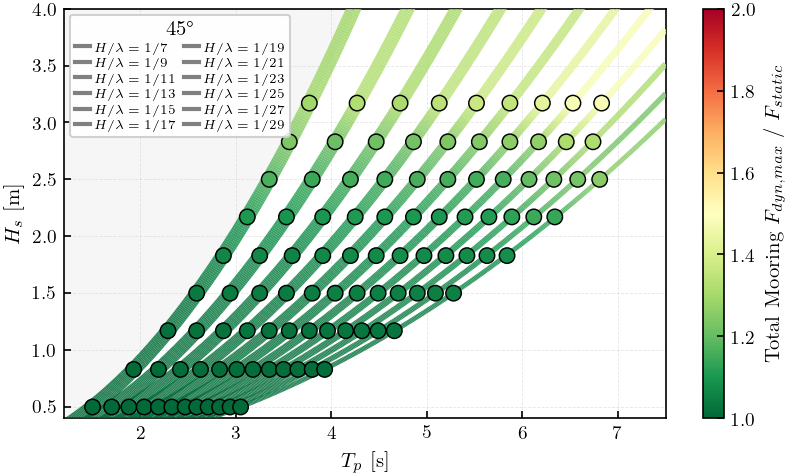

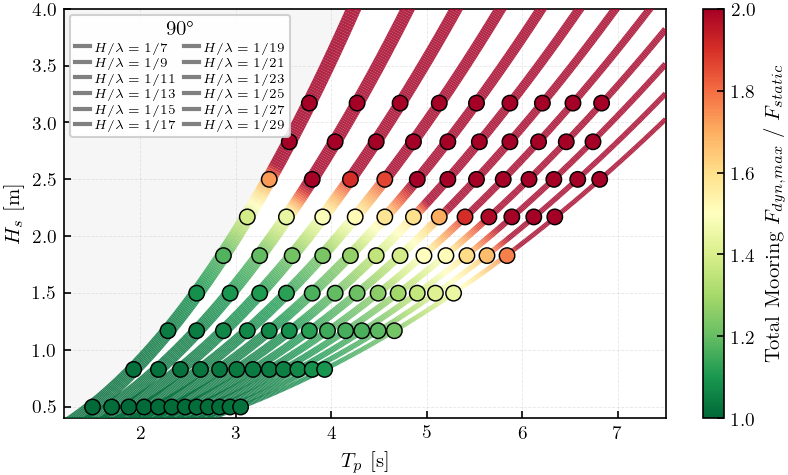

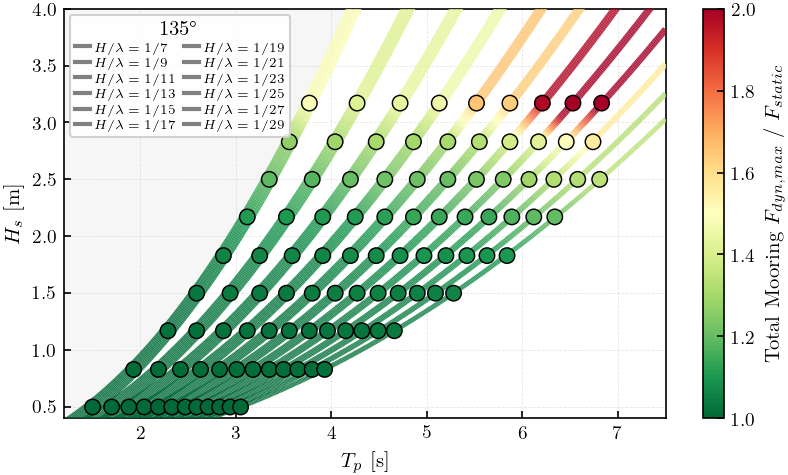

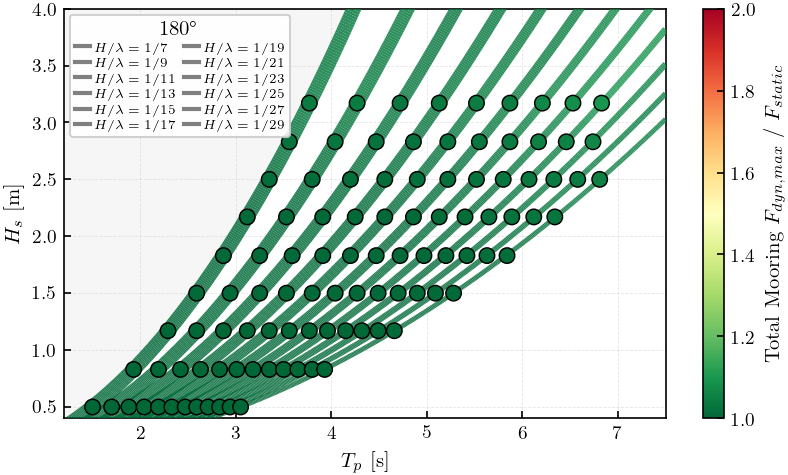

In [4]:
DAF_CMAP_MAX = 2.0
norm = Normalize(vmin=1.0, vmax=DAF_CMAP_MAX, clip=True)

def make_lc(x, y, daf_arr, lw):
    pts  = np.array([x, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='RdYlGn_r', norm=norm,
                          linewidth=lw, alpha=0.85, zorder=3)
    lc.set_array((daf_arr[:-1] + daf_arr[1:]) / 2)
    return lc

legend_handles = [plt.Line2D([0],[0], color='grey', lw=2.0, label=cfg['label'])
                  for cfg in LINES.values()]
_leg_kw = dict(fontsize=6, ncol=2, handlelength=1.2, columnspacing=0.6,
               handletextpad=0.4, borderpad=0.4, labelspacing=0.25)

def draw_panel(ax, heading):
    sub_h = sys_daf[sys_daf.heading == heading]
    sweep = np.linspace(0.3, 7.5, 600)
    ax.fill_between(sweep, g*sweep**2/(2*np.pi*7), 10,
                    color='lightgrey', alpha=0.2, zorder=0)
    sc_ref = None
    for line_name, cfg in LINES.items():
        y_curve = g*sweep**2/(2*np.pi*cfg['n'])
        sub      = sub_h[sub_h.line == line_name]
        daf_dict = dict(zip(sub.cond_num, sub['sys_DAF']))
        conds    = sorted(cfg['cond_params'])
        pts_x    = np.array([cfg['cond_params'][c][1] for c in conds])
        pts_y    = np.array([cfg['cond_params'][c][0] for c in conds])
        daf_pts  = np.array([daf_dict.get(c, np.nan) for c in conds])
        daf_interp = np.interp(sweep,
                               np.concatenate([[sweep[0]], pts_x]),
                               np.concatenate([[1.0], daf_pts]))
        ax.add_collection(make_lc(sweep, y_curve, daf_interp, cfg['lw']))
        sc = ax.scatter(pts_x, pts_y, c=daf_pts, cmap='RdYlGn_r', norm=norm,
                        s=55, zorder=5, edgecolors='black', linewidths=0.7)
        if sc_ref is None: sc_ref = sc
    ax.set_xlabel('$T_p$ [s]'); ax.set_ylabel('$H_s$ [m]')
    ax.set_xlim(1.2,7.5); ax.set_ylim(0.4,4.0)
    ax.grid(True, alpha=0.3)
    return sc_ref

for h in HEADINGS:
    fig, ax = plt.subplots(figsize=full())
    sc_ref = draw_panel(ax, h)
    ax.legend(handles=legend_handles, loc='upper left', **_leg_kw, title=f'{HEADING_LABELS[h]}')
    cb = plt.colorbar(sc_ref, ax=ax)
    cb.set_label(r'Total Mooring $F_{dyn,max}$ / $F_{static}$')
    plt.tight_layout(); save(fig, f'daf_mooring_sys_{h}'); plt.show()

## Heatmap — System Mooring DAF

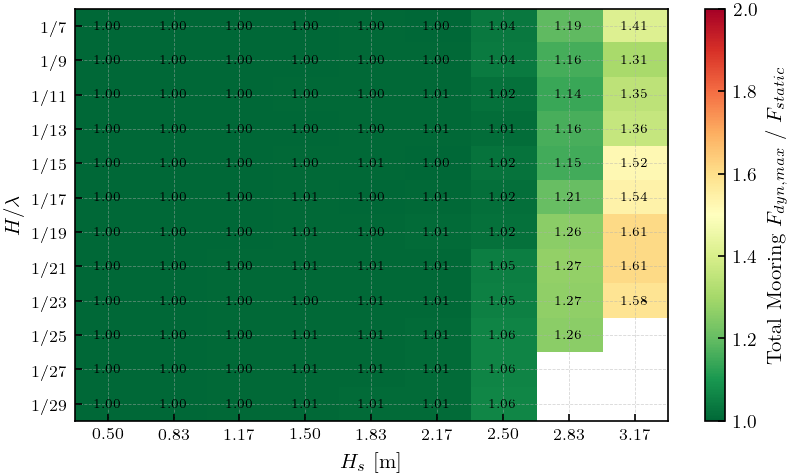

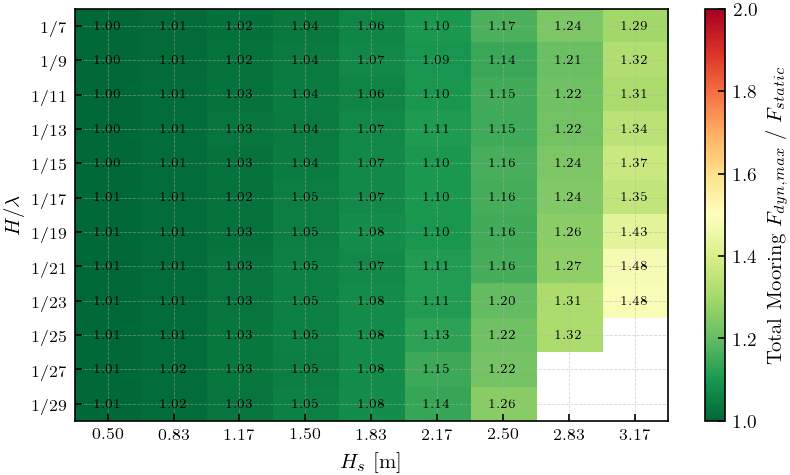

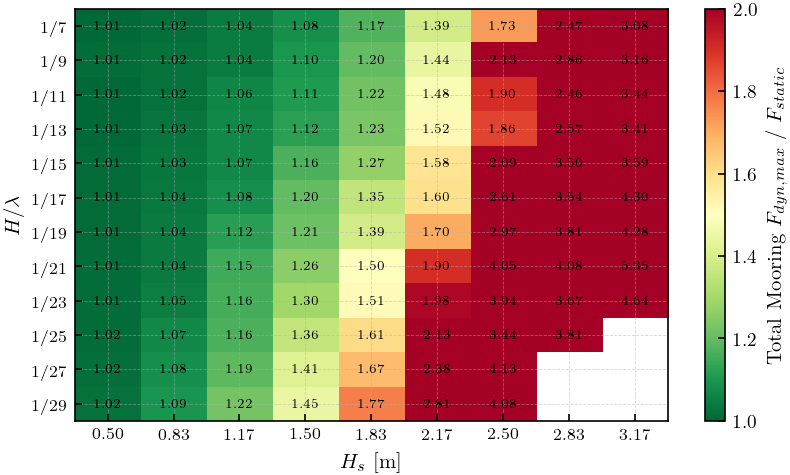

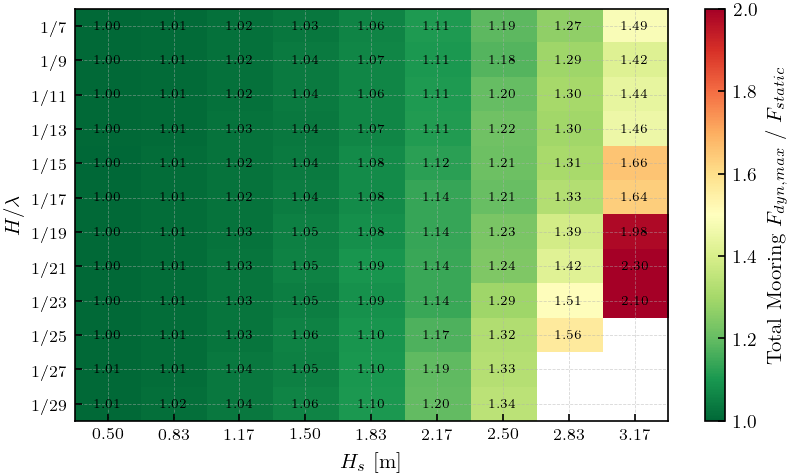

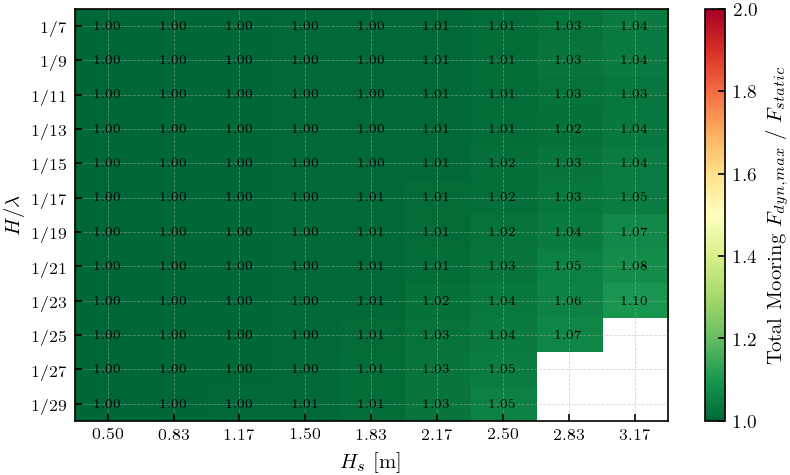

In [5]:
line_order = list(LINES.keys())
max_cond   = max(cfg['n_cond'] for cfg in LINES.values())
vmin, vmax = 1.0, 2.0

for h in HEADINGS:
    fig, ax = plt.subplots(figsize=full())
    sub_h = sys_daf[sys_daf.heading == h]
    mat = np.full((len(line_order), max_cond), np.nan)
    for r, ln in enumerate(line_order):
        for row in sub_h[sub_h.line == ln].itertuples():
            c = row.cond_num - 1
            if c < max_cond: mat[r,c] = row.sys_DAF
    im = ax.imshow(mat, aspect='auto', vmin=vmin, vmax=vmax,
                   cmap=plt.cm.RdYlGn_r, origin='upper', interpolation='none')
    ax.set_xticks(range(max_cond))
    ax.set_xticklabels([f'{HS_VALUES[i]:.2f}' for i in range(max_cond)], fontsize=8)
    ax.set_yticks(range(len(line_order))); ax.set_yticklabels(['$' + LINES[ln]['label'].split('= ')[1] for ln in line_order], fontsize=8)
    ax.set_xlabel('$H_s$ [m]'); ax.set_ylabel(r'$H/\lambda$')
    for r in range(len(line_order)):
        for c in range(max_cond):
            v = mat[r,c]
            if not np.isnan(v):
                ax.text(c, r, f'{v:.2f}', ha='center', va='center',
                        fontsize=6, color='black')
    cb = plt.colorbar(im, ax=ax)
    cb.set_label(r'Total Mooring $F_{dyn,max}$ / $F_{static}$')
    plt.tight_layout(); save(fig, f'daf_mooring_sys_heatmap_{h}'); plt.show()

## Heading Comparison — Max System Mooring DAF

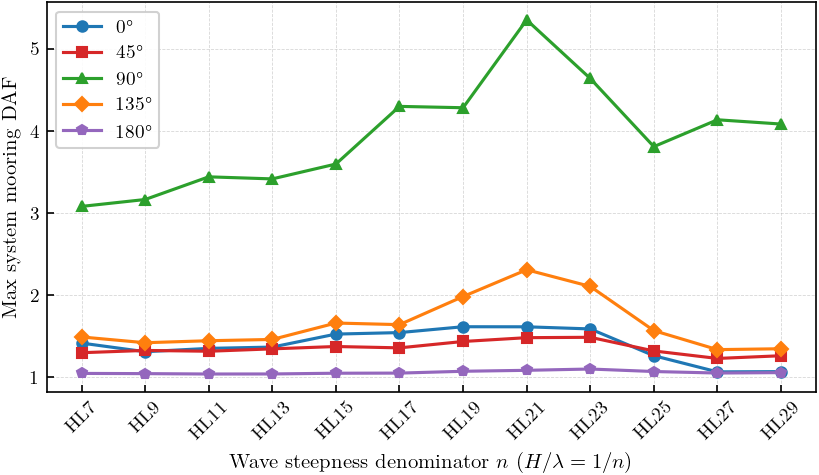

Max system mooring DAF per heading × steepness line
         0°   135°   180°    45°    90°
line                                   
HL7   1.412  1.486  1.042  1.294  3.077
HL9   1.306  1.416  1.039  1.322  3.161
HL11  1.347  1.440  1.035  1.312  3.437
HL13  1.363  1.456  1.035  1.341  3.412
HL15  1.521  1.656  1.044  1.370  3.593
HL17  1.539  1.636  1.046  1.353  4.295
HL19  1.611  1.978  1.068  1.431  4.279
HL21  1.610  2.305  1.080  1.477  5.349
HL23  1.584  2.102  1.096  1.482  4.635
HL25  1.258  1.563  1.065  1.316  3.805
HL27  1.061  1.332  1.047  1.224  4.132
HL29  1.064  1.343  1.052  1.257  4.080

Ratio 90° / 0°:
line
HL7     2.180
HL9     2.419
HL11    2.551
HL13    2.504
HL15    2.362
HL17    2.790
HL19    2.656
HL21    3.323
HL23    2.926
HL25    3.025
HL27    3.895
HL29    3.836


In [6]:
HEADING_COLORS  = {'0deg': '#1f77b4', '45deg': '#d62728', '90deg': '#2ca02c',
                   '135deg': '#ff7f0e', '180deg': '#9467bd'}
HEADING_MARKERS = {'0deg': 'o', '45deg': 's', '90deg': '^',
                   '135deg': 'D', '180deg': 'p'}

lines_order = list(LINES.keys())
HL_N        = {ln: LINES[ln]['n'] for ln in lines_order}

fig, ax = plt.subplots(figsize=full())
for h in HEADINGS:
    sub = (
        sys_daf[sys_daf.heading == h]
        .groupby('line')['sys_DAF'].max()
        .reset_index()
    )
    sub['n'] = sub['line'].map(HL_N)
    sub = sub[sub.line.isin(lines_order)].sort_values('n')
    ax.plot(sub['n'], sub['sys_DAF'],
            color=HEADING_COLORS[h], lw=1.5,
            marker=HEADING_MARKERS[h], ms=5,
            label=HEADING_LABELS[h])

ax.set_xlabel(r'Wave steepness denominator $n$  ($H/\lambda = 1/n$)')
ax.set_ylabel('Max system mooring DAF')
ax.set_xticks([HL_N[ln] for ln in lines_order])
ax.set_xticklabels(lines_order, rotation=45)
ax.legend()
plt.tight_layout()
save(fig, 'daf_sys_mooring_max_vs_steepness')
plt.show()

# Summary table
summary = (
    sys_daf.groupby(['heading', 'line'])['sys_DAF'].max()
    .unstack(level=0)
    .reindex([ln for ln in lines_order])
)
summary.columns = [HEADING_LABELS.get(h, h) for h in summary.columns]
print('Max system mooring DAF per heading × steepness line')
print(summary.round(3).to_string())
if '0°' in summary.columns and '90°' in summary.columns:
    print()
    ratio = (summary['90°'] / summary['0°']).round(3)
    print('Ratio 90° / 0°:')
    print(ratio.to_string())